In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from numpy import asarray
import numpy as np
import glob
import cv2
from numpy import zeros
from numpy import ones
from numpy.random import randn
# from numpy.random import randin
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
# from tensorflow.keras.utils.vis_utils import plot_model
from tensorflow.keras.models import Model,Sequential, load_model
from tensorflow.keras.layers import Input, MaxPooling2D, GlobalAveragePooling2D,UpSampling2D,Conv2DTranspose,LeakyReLU,Dropout,Activation,Dense,Flatten,Reshape,Conv2D, BatchNormalization

In [ ]:
# for dirname, _, filenames in os.walk(r'F:\DataSets\Gan dataset\train\4'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [ ]:
# len(filenames)

In [3]:
#Define input image dimensions
#Large images take too much time and resources.
Gan_dataset = glob.glob(r"F:\DataSets\Gan dataset\train\4\*.png")
img_rows = 224
img_cols = 224
channels = 3
img_shape = (img_rows, img_cols, channels)

In [4]:
data = []
# loop over the input images
for imagePath in Gan_dataset:
        # load the image, pre-process it, and store it in the data list
    image = cv2.imread(imagePath)
    image = cv2.resize(image, (224, 224))
    image = np.array(image)
    data.append(image)
        # extract the class label from the image path and update the
        # labels list
    dataset_orig = np.array(data, dtype="float")
        # Convert to float and Rescale -1 to 1 (Can also do 0 to 1)
    dataset_orig = (dataset_orig.astype(np.float32) - 127.5) / 127.5

In [5]:
dataset_orig.shape

(295, 224, 224, 3)

In [6]:
width, height, channel = 224, 224, 3
np.random.shuffle(dataset_orig)
X = dataset_orig

In [7]:
X.shape

(295, 224, 224, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

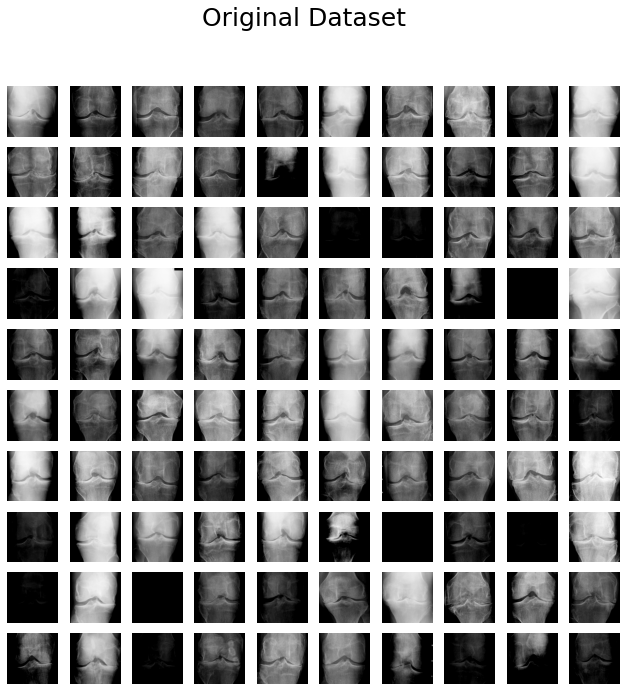

In [8]:
def show_data(X, title=""):
    plt.figure(figsize=(11,11))
    
    i = 1
    for img in X:
        plt.subplot(10, 10, i)
        plt.imshow(img.reshape((height, width,channel)))
        plt.axis('off')
        i+=1
        if i>100: break

    plt.suptitle(title, fontsize = 25)
    plt.show()
    
show_data(X, title="Original Dataset")

In [9]:
gen_optimizer = Adam(0.0002, 0.5)
disc_optimizer = Adam(0.0002, 0.5)
noise_dim = 100

In [14]:
def buildGenerator():
    model = Sequential()

    model.add(Dense(7*7*64, use_bias=False, input_shape=(100,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Reshape((7, 7, 64)))
    assert model.output_shape == (None, 7, 7, 64) # Note: None is the batch size

    model.add(Conv2DTranspose(256, (4,4), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    
    model.add(Conv2DTranspose(256, (4,4), strides=(2, 2), padding='same', use_bias=False))
#     assert model.output_shape == (None, 32, 32, 64)
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    
    model.add(Conv2DTranspose(256, (4,4), strides=(2, 2), padding='same', use_bias=False))
#     assert model.output_shape == (None, 32, 32, 64)
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    
    
    model.add(Conv2DTranspose(256, (4,4), strides=(2, 2), padding='same', use_bias=False))
#     assert model.output_shape == (None, 32, 32, 64)
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    
    model.add(Conv2DTranspose(256, (4,4), strides=(2, 2), padding='same', use_bias=False))
#     assert model.output_shape == (None, 32, 32, 64)
    model.add(BatchNormalization())
    model.add(LeakyReLU())


    model.add(Conv2DTranspose(3, (3,3), strides=(1,1), padding='same', use_bias=False, activation='sigmoid'))
#     assert model.output_shape == (None, 64, 64, 3)
    
    return model

In [15]:
generator = buildGenerator()
generator.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 3136)              313600    
                                                                 
 batch_normalization_7 (Batc  (None, 3136)             12544     
 hNormalization)                                                 
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 3136)              0         
                                                                 
 reshape_2 (Reshape)         (None, 7, 7, 64)          0         
                                                                 
 conv2d_transpose_6 (Conv2DT  (None, 14, 14, 256)      262144    
 ranspose)                                                       
                                                                 
 batch_normalization_8 (Batc  (None, 14, 14, 256)     

In [16]:
def buildDiscriminator():
    model = Sequential()
    
    model.add(Conv2D(256, (4,4), strides=(2, 2), padding='same', input_shape=(width, height, channel)))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    model.add(Conv2D(128, (4,4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))
    
    model.add(Conv2D(64, (4,4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))
    
    model.add(Conv2D(32, (4,4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))
    
    model.add(Conv2D(16, (4,4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))
    
    model.add(Flatten())
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy', optimizer=disc_optimizer)
    return model

In [17]:
discriminator = buildDiscriminator()
discriminator.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 112, 112, 256)     12544     
                                                                 
 leaky_re_lu_13 (LeakyReLU)  (None, 112, 112, 256)     0         
                                                                 
 dropout (Dropout)           (None, 112, 112, 256)     0         
                                                                 
 conv2d_1 (Conv2D)           (None, 56, 56, 128)       524416    
                                                                 
 leaky_re_lu_14 (LeakyReLU)  (None, 56, 56, 128)       0         
                                                                 
 dropout_1 (Dropout)         (None, 56, 56, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 64)       

In [18]:
noise = Input(shape=(noise_dim,))
fake_data = generator(noise)
discriminator.trainable = False
output = discriminator(fake_data)
gan = Model(noise, output)
gan.compile(loss='binary_crossentropy', optimizer=gen_optimizer)

In [19]:
gan.summary()
# plot the model
# plot_model(gan, to_file='gan_plot.png', show_shapes=True, show_layer_names=True)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 100)]             0         
                                                                 
 sequential_2 (Sequential)   (None, 224, 224, 3)       4794624   
                                                                 
 sequential_3 (Sequential)   (None, 1)                 709889    
                                                                 
Total params: 5,504,513
Trainable params: 4,785,792
Non-trainable params: 718,721
_________________________________________________________________


In [20]:
fixed_noise = np.random.normal(0, 1, size=(100, noise_dim))

In [27]:
def show_generated_fabric(title, epoch):
    imgs = generator.predict(fixed_noise)
    imgs = 0.5 * imgs + 0.5
    plt.figure(figsize=(11,11))
    
    i = 1
    for img in imgs:
        plt.subplot(3, 3, i)
        plt.imshow(img.reshape((height,width,channel)))
        plt.axis('off')
        i+=1
        if i>1: break
    plt.suptitle(title, fontsize = 10)
    plt.savefig("img_"+str(epoch+1)+".png", transparent=True)
    plt.clf()
    plt.show()

In [30]:
epochs = 10
batch_size = 8
steps_per_epoch = len(X)//batch_size

0
1/1 [==============================] - 0s 45ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 40ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 42ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 40ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 39ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 45ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 41ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 41ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 43ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 47ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 39ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 41ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 42ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 41ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 44ms/step
1
2
3
4
5
0
1/1 [==============================] -

C:\Users\DR.Zoz\AppData\Local\Temp\ipykernel_2472\2397256405.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


1
2
3
4
5
0
1/1 [==============================] - 0s 48ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 50ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 43ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 41ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 49ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 41ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 43ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 44ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 43ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 47ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 49ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 42ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 86ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 78ms/step
1
2
3
4
5
0
1/1 [==============================] - 0s 43ms/step
1
2
3
4
5
epoch:  0
discriminator loss: 

ResourceExhaustedError: Graph execution error:

Detected at node 'sequential_2/conv2d_transpose_10/conv2d_transpose' defined at (most recent call last):
    File "C:\Users\DR.Zoz\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\DR.Zoz\anaconda3\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "C:\Users\DR.Zoz\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
      app.launch_new_instance()
    File "C:\Users\DR.Zoz\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
      app.start()
    File "C:\Users\DR.Zoz\anaconda3\lib\site-packages\ipykernel\kernelapp.py", line 677, in start
      self.io_loop.start()
    File "C:\Users\DR.Zoz\anaconda3\lib\site-packages\tornado\platform\asyncio.py", line 199, in start
      self.asyncio_loop.run_forever()
    File "C:\Users\DR.Zoz\anaconda3\lib\asyncio\base_events.py", line 601, in r

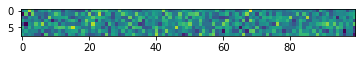

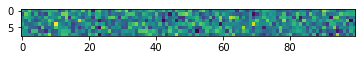

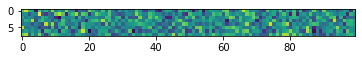

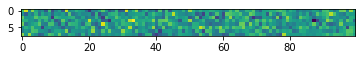

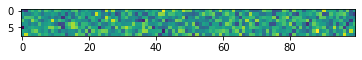

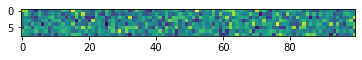

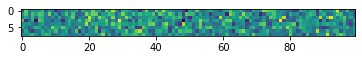

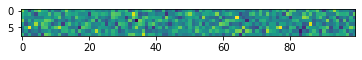

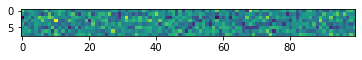

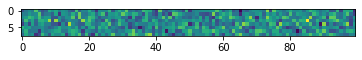

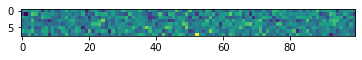

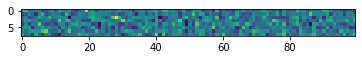

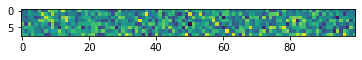

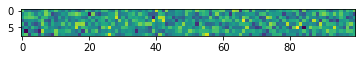

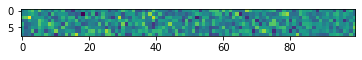

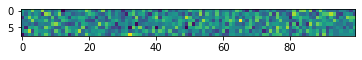

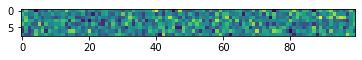

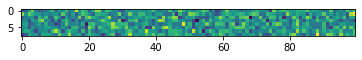

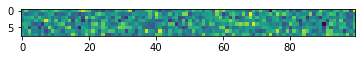

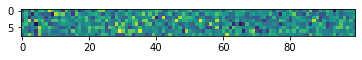

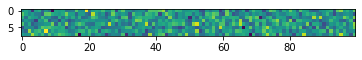

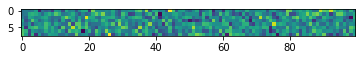

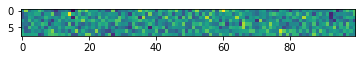

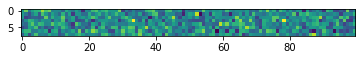

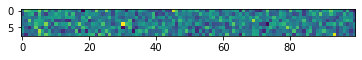

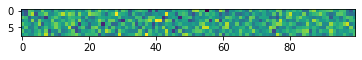

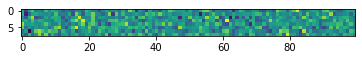

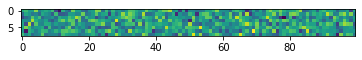

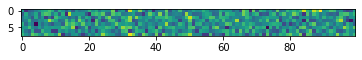

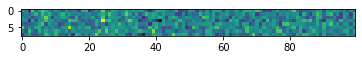

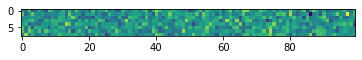

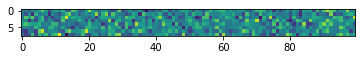

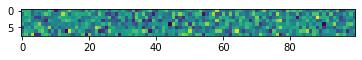

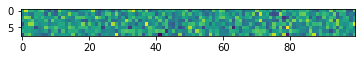

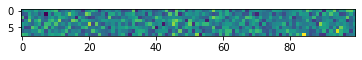

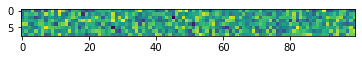

In [31]:
for epoch in range(epochs):
    for batch in range(steps_per_epoch):
        print('0')
        input_gen = np.random.normal(0, 1, size=(batch_size, noise_dim))
        #print('the input for gan is ', input_gen)
        plt.figure()
        plt.imshow(input_gen)
        fake_data = generator.predict(input_gen)
        print('1')
        real_data = X[np.random.randint(0, X.shape[0], size=batch_size)]
        real_data = real_data.reshape((batch_size, width, height, channel))
        print('2')
        input_disc = np.concatenate((real_data, fake_data))

        label_disc = np.zeros(2*batch_size)
        label_disc[:batch_size] = 0.9
        label_disc[batch_size:] = 0.1
        loss_disc = discriminator.train_on_batch(input_disc, label_disc)
        print('3')
        label_gen = np.ones(batch_size)
        print('4')
        loss_gen = gan.train_on_batch(input_gen, label_gen)
        print('5')
    print("epoch: ", epoch)
    print("discriminator loss: ", loss_disc)
    print("generator loss: ", loss_gen)
    print("-"*80)
    
    if (epoch+1) % 1 == 0:
        show_generated_fabric("Generated Fabric", epoch)
        filename = 'generator_model_%03d.h5' % (epoch+1)
        generator.save(filename)